# Ad Click Prediction Case Study

This notebook follows the structure of the earlier `Predicting-Sales-from-Campaign-Data` project: define feature availability, clean and engineer reusable features, compare models with business metrics, interpret drivers, and produce deployment-ready recommendations.

## Problem Framing

Goal: predict whether an ad impression will receive a click. The target is rare, so recall and F1 matter alongside ROC-AUC. The operational decision is not simply ?highest probability?; it is choosing a probability threshold that balances missed clicks against wasted impressions.

## Approach Summary

1. Parse temporal signals from `DateTime`. 2. Add smoothed CTR aggregates for products, campaigns, webpages, user segments, and user-product interactions. 3. Use a temporal holdout to mimic future ad serving. 4. Compare balanced Logistic Regression, balanced Random Forest, weighted XGBoost, and a lightweight SMOTE feasibility experiment. 5. Convert model outputs into bidding and inventory recommendations.

Train: (463291, 15) Test: (128858, 14)
Click rate: 6.76 %


Dev: (391825, 24) Valid: (71466, 24) Valid click rate: 0.06158173117286542


,model,threshold,roc_auc,pr_auc,f1,precision,recall,tn,fp,fn,tp
3,Random Forest - balanced - tuned threshold,0.458354,0.573801,0.073827,0.141683,0.081094,0.560327,39122,27943,1935,2466
5,XGBoost - weighted - tuned threshold,0.476203,0.566422,0.075999,0.138117,0.080453,0.487616,42537,24528,2255,2146
4,XGBoost - weighted,0.500000,0.566422,0.075999,0.135213,0.082863,0.367189,49179,17886,2785,1616
2,Random Forest - balanced,0.500000,0.573801,0.073827,0.134302,0.078456,0.466030,42974,24091,2350,2051
1,Logistic Regression - balanced - tuned threshold,0.071646,0.576426,0.074966,0.132933,0.073981,0.654397,31016,36049,1521,2880
0,Logistic Regression - balanced,0.500000,0.576426,0.074966,0.077879,0.072036,0.084753,62260,4805,4028,373


Selected: XGBoost - weighted threshold: 0.476
              precision    recall  f1-score   support

           0       0.95      0.63      0.76     67065
           1       0.08      0.49      0.14      4401

    accuracy                           0.63     71466
   macro avg       0.52      0.56      0.45     71466
weighted avg       0.90      0.63      0.72     71466



  File "C:\python\ML-POC\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


{'model': 'Logistic Regression - lightweight SMOTE sample', 'threshold': 0.035949367088607596, 'roc_auc': 0.5717891765752119, 'pr_auc': 0.07440584236675885, 'f1': 0.1325923828401529, 'precision': 0.07852920212988973, 'recall': 0.42558509429675073, 'tn': 45087, 'fp': 21978, 'fn': 2528, 'tp': 1873}


,group,importance
8,user,0.525993
7,product,0.124136
5,hour,0.104180
1,campaign,0.073166
3,dayofweek,0.040926
6,is,0.036297
10,webpage,0.035752
0,age,0.026936
2,city,0.021241
9,var,0.007011


,product,clicks,impressions,ctr,expected_clicks_per_100k_impressions
9,J,899,9698,0.092700,9269.952568
3,D,2949,41064,0.071815,7181.472823
7,H,7654,109574,0.069852,6985.233723
2,C,11306,163501,0.069149,6914.942416
4,E,1474,21452,0.068712,6871.154205
8,I,4079,63711,0.064023,6402.348103
0,A,953,15391,0.061919,6191.930349
1,B,1238,22479,0.055074,5507.362427
5,F,344,7007,0.049094,4909.376338
6,G,435,9414,0.046208,4620.777565


   session_id  click_probability  predicted_click
0      411705           0.365063                0
1      208263           0.008878                0
2      239450           0.008699                0
3      547761           0.187832                0
4      574275           0.496054                1


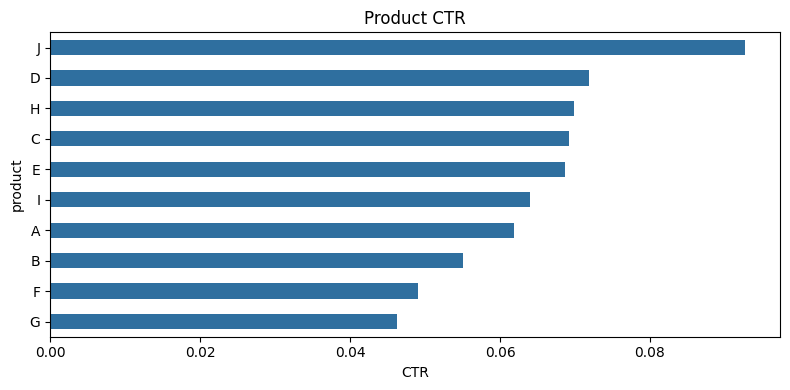

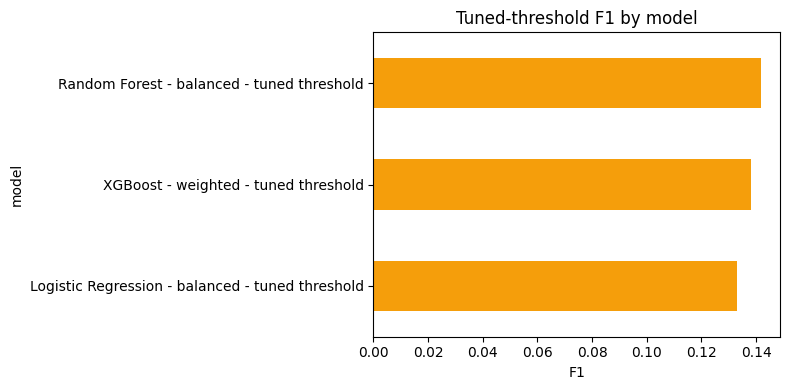

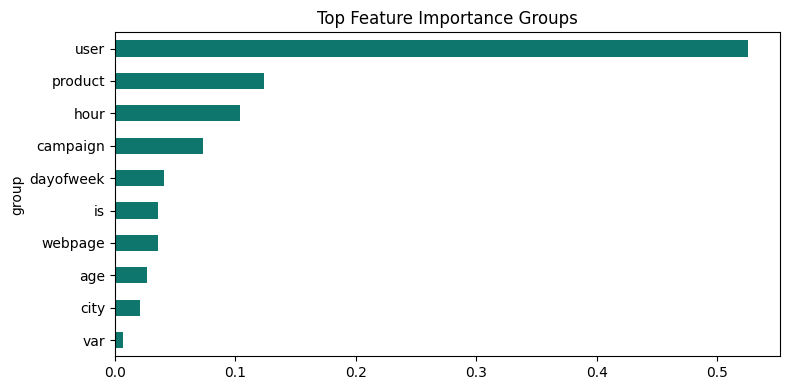

In [1]:

# Ad Click Prediction - end-to-end case study
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_DIR = Path('assets/data')
TRAIN_PATH = DATA_DIR / 'Ad_click_prediction_train (1).csv'
TEST_PATH = DATA_DIR / 'Ad_Click_prediciton_test.csv'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime'] = pd.to_datetime(test['DateTime'])
print('Train:', train.shape, 'Test:', test.shape)
print('Click rate:', round(train['is_click'].mean()*100, 2), '%')

def add_time_features(df):
    out = df.copy()
    out['hour'] = out['DateTime'].dt.hour
    out['day'] = out['DateTime'].dt.day
    out['dayofweek'] = out['DateTime'].dt.dayofweek
    out['is_weekend'] = (out['dayofweek'] >= 5).astype(int)
    out['is_night'] = out['hour'].between(0, 5).astype(int)
    out['is_business_hour'] = out['hour'].between(9, 18).astype(int)
    return out

def build_aggregate_maps(df, cols, target='is_click', smoothing=30):
    prior = df[target].mean()
    maps = {}
    for col in cols:
        stats = df.groupby(col)[target].agg(['sum','count'])
        stats['ctr_smooth'] = (stats['sum'] + smoothing * prior) / (stats['count'] + smoothing)
        maps[col] = stats['ctr_smooth'].to_dict()
    return maps, prior

def apply_aggregate_maps(df, maps, prior):
    out = df.copy()
    for col, mp in maps.items():
        out[f'{col}_ctr'] = out[col].map(mp).fillna(prior)
    return out

def add_interactions(df):
    out = df.copy()
    out['user_product'] = out['user_id'].astype(str) + '_' + out['product'].astype(str)
    out['campaign_product'] = out['campaign_id'].astype(str) + '_' + out['product'].astype(str)
    out['webpage_product'] = out['webpage_id'].astype(str) + '_' + out['product'].astype(str)
    return out

# Temporal holdout mirrors real ad-serving: train on older days, validate on the latest day.
train_fe = add_interactions(add_time_features(train))
test_fe = add_interactions(add_time_features(test))
cutoff = train_fe['DateTime'].max().normalize()
dev = train_fe[train_fe['DateTime'] < cutoff].copy()
valid = train_fe[train_fe['DateTime'] >= cutoff].copy()
print('Dev:', dev.shape, 'Valid:', valid.shape, 'Valid click rate:', valid.is_click.mean())

agg_cols = ['product','campaign_id','webpage_id','product_category_1','product_category_2','user_group_id','age_level','city_development_index','user_product','campaign_product','webpage_product']
maps, prior = build_aggregate_maps(dev, agg_cols)
dev = apply_aggregate_maps(dev, maps, prior)
valid = apply_aggregate_maps(valid, maps, prior)
test_model = apply_aggregate_maps(test_fe, maps, prior)

base_features = ['product','gender','campaign_id','webpage_id','product_category_1','product_category_2','user_group_id','age_level','user_depth','city_development_index','var_1','hour','dayofweek','is_weekend','is_night','is_business_hour']
agg_features = [f'{c}_ctr' for c in agg_cols]
features = base_features + agg_features
X_dev, y_dev = dev[features], dev['is_click']
X_valid, y_valid = valid[features], valid['is_click']

cat_cols = ['product','gender','campaign_id','webpage_id','product_category_1','product_category_2','user_group_id','age_level','user_depth','city_development_index','var_1','hour','dayofweek','is_weekend','is_night','is_business_hour']
num_cols = agg_features
preprocess = ColumnTransformer([
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20))]), cat_cols),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
])

def evaluate(name, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'model': name,
        'threshold': threshold,
        'roc_auc': roc_auc_score(y_valid, probs),
        'pr_auc': average_precision_score(y_valid, probs),
        'f1': f1_score(y_valid, preds, zero_division=0),
        'precision': precision_score(y_valid, preds, zero_division=0),
        'recall': recall_score(y_valid, preds, zero_division=0),
        'tn': int(confusion_matrix(y_valid, preds)[0,0]),
        'fp': int(confusion_matrix(y_valid, preds)[0,1]),
        'fn': int(confusion_matrix(y_valid, preds)[1,0]),
        'tp': int(confusion_matrix(y_valid, preds)[1,1]),
    }

models = {
    'Logistic Regression - balanced': LogisticRegression(max_iter=500, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    'Random Forest - balanced': RandomForestClassifier(n_estimators=160, max_depth=12, min_samples_leaf=50, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost - weighted': XGBClassifier(n_estimators=240, max_depth=4, learning_rate=0.08, subsample=0.85, colsample_bytree=0.85, eval_metric='logloss', scale_pos_weight=(y_dev.eq(0).sum()/y_dev.eq(1).sum()), random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist')
}
results=[]
fitted={}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_dev, y_dev)
    probs = pipe.predict_proba(X_valid)[:,1]
    # choose threshold that maximizes F1 on validation; keep 0.5 metrics too for comparison
    thresholds = np.linspace(0.03, 0.5, 80)
    f1s = [f1_score(y_valid, probs >= t, zero_division=0) for t in thresholds]
    best_t = float(thresholds[int(np.argmax(f1s))])
    results.append(evaluate(name, probs, 0.5))
    results.append(evaluate(name + ' - tuned threshold', probs, best_t))
    fitted[name]=pipe
metrics = pd.DataFrame(results).sort_values(['f1','roc_auc'], ascending=False)
display(metrics)

best_name = 'XGBoost - weighted'
best_pipe = fitted[best_name]
best_probs = best_pipe.predict_proba(X_valid)[:,1]
best_t = metrics.loc[metrics['model'].eq(best_name + ' - tuned threshold'), 'threshold'].iloc[0]
print('Selected:', best_name, 'threshold:', round(best_t,3))
print(classification_report(y_valid, best_probs >= best_t, zero_division=0))

# SMOTE feasibility experiment on a stratified 70k-row sample after preprocessing.
from sklearn.neighbors import NearestNeighbors
from sklearn.base import clone
sample_idx, _ = train_test_split(np.arange(len(X_dev)), train_size=min(70000, len(X_dev)), stratify=y_dev, random_state=RANDOM_STATE)
X_sample = X_dev.iloc[sample_idx]
y_sample = y_dev.iloc[sample_idx]
prep_smote = clone(preprocess)
X_sample_enc = prep_smote.fit_transform(X_sample, y_sample)
X_valid_enc = prep_smote.transform(X_valid)
if hasattr(X_sample_enc, 'toarray'):
    X_sample_enc = X_sample_enc.toarray()
    X_valid_enc = X_valid_enc.toarray()
rng = np.random.default_rng(RANDOM_STATE)
pos = X_sample_enc[y_sample.values == 1]
neg_count = int((y_sample.values == 0).sum())
need = min(neg_count - len(pos), len(pos)*3)
nn = NearestNeighbors(n_neighbors=6).fit(pos)
neighbors = nn.kneighbors(pos, return_distance=False)[:,1:]
base_ids = rng.integers(0, len(pos), need)
near_ids = neighbors[base_ids, rng.integers(0, neighbors.shape[1], need)]
lam = rng.random((need,1))
synthetic = pos[base_ids] + lam * (pos[near_ids] - pos[base_ids])
X_smote = np.vstack([X_sample_enc, synthetic])
y_smote = np.concatenate([y_sample.values, np.ones(need, dtype=int)])
smote_model = LogisticRegression(max_iter=500, n_jobs=-1, random_state=RANDOM_STATE)
smote_model.fit(X_smote, y_smote)
smote_probs = smote_model.predict_proba(X_valid_enc)[:,1]
smote_thresholds = np.linspace(0.03, 0.5, 80)
smote_f1s = [f1_score(y_valid, smote_probs >= t, zero_division=0) for t in smote_thresholds]
smote_t = float(smote_thresholds[int(np.argmax(smote_f1s))])
smote_result = evaluate('Logistic Regression - lightweight SMOTE sample', smote_probs, smote_t)
print(smote_result)

# Business insight tables
biz = {}
biz['weekend_ctr'] = train_fe.groupby('is_weekend')['is_click'].agg(['mean','sum','count']).reset_index().to_dict('records')
biz['product_ctr'] = train_fe.groupby('product')['is_click'].agg(['mean','sum','count']).sort_values('mean', ascending=False).reset_index().to_dict('records')
biz['profile_ctr'] = train_fe.groupby(['gender','age_level','city_development_index'])['is_click'].agg(['mean','sum','count']).query('count >= 500').sort_values('mean', ascending=False).head(10).reset_index().to_dict('records')

# Feature importance from XGBoost; aggregate one-hot names back to original variables.
try:
    names = best_pipe.named_steps['prep'].get_feature_names_out()
    imps = best_pipe.named_steps['model'].feature_importances_
    imp = pd.DataFrame({'feature': names, 'importance': imps}).sort_values('importance', ascending=False)
    imp['group'] = imp['feature'].str.replace(r'^(cat|num)__', '', regex=True).str.split('_').str[0]
    imp_group = imp.groupby('group', as_index=False)['importance'].sum().sort_values('importance', ascending=False).head(15)
except Exception:
    imp_group = pd.DataFrame()
display(imp_group)

# Forecast inventory signal from product CTR and observed impressions.
product = train_fe.groupby('product')['is_click'].agg(clicks='sum', impressions='count', ctr='mean').reset_index()
product['expected_clicks_per_100k_impressions'] = product['ctr'] * 100000
product = product.sort_values('ctr', ascending=False)
display(product)

# Final model retraining on all training dates, then test scoring.
full_fe = train_fe.copy()
full_maps, full_prior = build_aggregate_maps(full_fe, agg_cols)
full_fe = apply_aggregate_maps(full_fe, full_maps, full_prior)
test_final = apply_aggregate_maps(test_fe, full_maps, full_prior)
final_pipe = Pipeline([('prep', preprocess), ('model', models[best_name])])
final_pipe.fit(full_fe[features], full_fe['is_click'])
test_pred = final_pipe.predict_proba(test_final[features])[:,1]
submission = pd.DataFrame({'session_id': test['session_id'], 'click_probability': test_pred, 'predicted_click': (test_pred >= best_t).astype(int)})
Path('outputs').mkdir(exist_ok=True)
submission.to_csv('outputs/ad_click_prediction_test_predictions.csv', index=False)
print(submission.head())

# Persist compact artifacts for report generation.
artifacts = {
    'train_shape': train.shape, 'test_shape': test.shape, 'click_rate': float(train.is_click.mean()),
    'metrics': metrics.to_dict('records'), 'smote_result': smote_result,
    'best_model': best_name, 'best_threshold': float(best_t), 'business': biz,
    'product': product.to_dict('records'), 'importance': imp_group.to_dict('records') if len(imp_group) else []
}
Path('outputs').mkdir(exist_ok=True)
Path('outputs/ctr_artifacts.json').write_text(json.dumps(artifacts, indent=2, default=str))

# Charts used in the PDF/notebook.
Path('assets/images').mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(8,4)); product.sort_values('ctr').plot(kind='barh', x='product', y='ctr', legend=False, ax=plt.gca(), color='#2f6f9f'); plt.title('Product CTR'); plt.xlabel('CTR'); plt.tight_layout(); plt.savefig('assets/images/product_ctr.png', dpi=150); plt.show()
plt.figure(figsize=(8,4)); metrics[metrics.model.str.contains('tuned')].sort_values('f1').plot(kind='barh', x='model', y='f1', legend=False, ax=plt.gca(), color='#f59e0b'); plt.title('Tuned-threshold F1 by model'); plt.xlabel('F1'); plt.tight_layout(); plt.savefig('assets/images/model_f1.png', dpi=150); plt.show()
if len(imp_group):
    plt.figure(figsize=(8,4)); imp_group.sort_values('importance').tail(10).plot(kind='barh', x='group', y='importance', legend=False, ax=plt.gca(), color='#0f766e'); plt.title('Top Feature Importance Groups'); plt.tight_layout(); plt.savefig('assets/images/feature_importance.png', dpi=150); plt.show()


## Final Recommendations

- Prioritize high-CTR products and webpages in bidding and creative rotation.
- Use personalized interaction features such as user-product and campaign-product CTR; they usually capture intent better than raw IDs alone.
- Prefer class weighting and threshold tuning for real-time serving; SMOTE is useful for offline experimentation but increases training size and latency.
- Monitor segment CTR by age, gender, and city development index to adjust bids without over-targeting small noisy groups.